### Create AnnData object for GSE99457 — Yan/Kuo 2017, mouse intestine scRNA-seq (Lgr5⁺ vs Bmi1⁺ vs Prox1⁺)

- **Developed by:** Anna Maguza
- **Affiliation:** Faculty of Medicine, Würzburg University
- **Date of creation:** 7 May 2026
- **Last modified date:** 7 May 2026

Builds an AnnData from the 8 samples deposited at `LGR5_analysis_data/GSE99457_RAW/` (10x Chromium MTX trios per sample). LGR5 sort gates are explicit in the GSM filenames: `Lgr5eGFP_pos_{1,2}` and `Lgr5eGFP_pos_{1,2}` are FACS-sorted Lgr5-eGFP⁺ ISCs, `Lgr5eGFP_neg_{1,2}` are sorted Lgr5-eGFP⁻ controls; `Bmi1_{1,2}`, `Prox1_{1,2}`, `original_Prox1_{1,2}` are comparator populations. See `LGR5_data_folder_inventory.md` and `GSE_datasets_Lgr5_intestinal_stem_cells.md` (entry §12) for the scientific design.

⚠️ `GSM2644354_Prox1_2` is a near-empty sample (~25 cells) — kept here, flagged in `processing_history` for a downstream QC step to drop.

### Import packages

In [1]:
import os
from datetime import datetime

import anndata as ad
import numpy as np
import pandas as pd
import scanpy as sc
import scipy as sci
from scipy.io import mmread

/Users/am336941/uv_envs/pyenv313/.venv/lib/python3.11/site-packages/scanpy/_utils/__init__.py:33: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  from anndata import __version__ as anndata_version
/Users/am336941/uv_envs/pyenv313/.venv/lib/python3.11/site-packages/scanpy/__init__.py:24: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):
/Users/am336941/uv_envs/pyenv313/.venv/lib/python3.11/site-packages/scanpy/readwrite.py:16: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):


In [2]:
def X_is_raw(adata):
    return np.array_equal(adata.X.sum(axis=0).astype(int), adata.X.sum(axis=0))

### Per-sample metadata

Sample → `{prefix on disk, lgr5_status, lgr5_label_raw, condition, cell_type}`. The prefix is everything before `barcodes.tsv.gz` / `genes.tsv.gz` / `matrix.mtx.gz` in the GEO upload. `lgr5_status` ∈ {`LGR5+`, `LGR5-`, `unknown`} for cross-dataset filtering; `lgr5_label_raw` preserves the GEO experimental label.

In [3]:
DATA_DIR = '/Users/am336941/PhD/data/LGR5_analysis_data/GSE99457_RAW'

SAMPLES = {
    'GSM2644345_original_Prox1_1': {'sample': 'original_Prox1_1', 'lgr5_status': 'unknown', 'lgr5_label_raw': 'original-Prox1+',     'condition': 'original-Prox1', 'cell_type': 'Prox1+ progenitor'},
    'GSM2644346_original_Prox1_2': {'sample': 'original_Prox1_2', 'lgr5_status': 'unknown', 'lgr5_label_raw': 'original-Prox1+',     'condition': 'original-Prox1', 'cell_type': 'Prox1+ progenitor'},
    'GSM2644347_Bmi1_1':           {'sample': 'Bmi1_1',           'lgr5_status': 'unknown', 'lgr5_label_raw': 'Bmi1-GFP+',           'condition': 'Bmi1+',          'cell_type': 'Bmi1+ ISC'},
    'GSM2644348_Bmi1_2':           {'sample': 'Bmi1_2',           'lgr5_status': 'unknown', 'lgr5_label_raw': 'Bmi1-GFP+',           'condition': 'Bmi1+',          'cell_type': 'Bmi1+ ISC'},
    'GSM2644349_Lgr5eGFP_neg_1':   {'sample': 'Lgr5eGFP_neg_1',   'lgr5_status': 'LGR5-',   'lgr5_label_raw': 'Lgr5-eGFP-neg',       'condition': 'Lgr5-eGFP-neg',  'cell_type': 'Lgr5- non-ISC'},
    'GSM2644350_Lgr5eGFP_neg_2':   {'sample': 'Lgr5eGFP_neg_2',   'lgr5_status': 'LGR5-',   'lgr5_label_raw': 'Lgr5-eGFP-neg',       'condition': 'Lgr5-eGFP-neg',  'cell_type': 'Lgr5- non-ISC'},
    'GSM2644351_Lgr5eGFP_pos_1':   {'sample': 'Lgr5eGFP_pos_1',   'lgr5_status': 'LGR5+',   'lgr5_label_raw': 'Lgr5-eGFP-pos',       'condition': 'Lgr5-eGFP-pos',  'cell_type': 'Lgr5+ ISC'},
    'GSM2644352_Lgr5eGFP_pos_2':   {'sample': 'Lgr5eGFP_pos_2',   'lgr5_status': 'LGR5+',   'lgr5_label_raw': 'Lgr5-eGFP-pos',       'condition': 'Lgr5-eGFP-pos',  'cell_type': 'Lgr5+ ISC'},
    'GSM2644353_Prox1_1':          {'sample': 'Prox1_1',          'lgr5_status': 'unknown', 'lgr5_label_raw': 'Prox1+',              'condition': 'Prox1+',         'cell_type': 'Prox1+ progenitor'},
    'GSM2644354_Prox1_2':          {'sample': 'Prox1_2',          'lgr5_status': 'unknown', 'lgr5_label_raw': 'Prox1+',              'condition': 'Prox1+',         'cell_type': 'Prox1+ progenitor'},
}

### Load each 10x trio and build a per-sample AnnData

In [4]:
def load_10x_sample(data_dir, prefix, meta):
    bc_path  = os.path.join(data_dir, f'{prefix}_mex_mm10_barcodes.tsv.gz')
    gn_path  = os.path.join(data_dir, f'{prefix}_mex_mm10_genes.tsv.gz')
    mtx_path = os.path.join(data_dir, f'{prefix}_mex_mm10_matrix.mtx.gz')

    barcodes = pd.read_csv(bc_path, sep='\t', header=None, names=['cell_barcode'])
    genes    = pd.read_csv(gn_path, sep='\t', header=None, names=['gene_id', 'gene_name'])
    matrix   = sci.sparse.csr_matrix(mmread(mtx_path)).T  # mtx is genes × cells; transpose to cells × genes

    obs = barcodes.copy()
    obs['cell_id'] = obs['cell_barcode'].astype(str) + '_' + meta['sample']
    for k, v in meta.items():
        obs[k] = v
    obs = obs.set_index('cell_id')

    var = genes.set_index('gene_name')
    var.index.name = None  # var_names are gene symbols

    a = ad.AnnData(X=matrix, obs=obs, var=var)
    a.var_names_make_unique()
    return a

adatas = {prefix: load_10x_sample(DATA_DIR, prefix, meta) for prefix, meta in SAMPLES.items()}
{k: v.shape for k, v in adatas.items()}

/Users/am336941/uv_envs/pyenv313/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1798: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/Users/am336941/uv_envs/pyenv313/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1798: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/Users/am336941/uv_envs/pyenv313/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1798: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/Users/am336941/uv_envs/pyenv313/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1798: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/Users/am336941/uv_envs/pyenv313/.venv/lib/python3.11/site-packages/annd

{'GSM2644345_original_Prox1_1': (521, 27998),
 'GSM2644346_original_Prox1_2': (537, 27998),
 'GSM2644347_Bmi1_1': (266, 27998),
 'GSM2644348_Bmi1_2': (448, 27998),
 'GSM2644349_Lgr5eGFP_neg_1': (967, 27998),
 'GSM2644350_Lgr5eGFP_neg_2': (789, 27998),
 'GSM2644351_Lgr5eGFP_pos_1': (804, 27998),
 'GSM2644352_Lgr5eGFP_pos_2': (960, 27998),
 'GSM2644353_Prox1_1': (234, 27998),
 'GSM2644354_Prox1_2': (44, 27998)}

In [5]:
adata = ad.concat(adatas, join='outer', label='GSM', index_unique=None, fill_value=0)
adata

AnnData object with n_obs × n_vars = 5570 × 27998
    obs: 'cell_barcode', 'sample', 'lgr5_status', 'lgr5_label_raw', 'condition', 'cell_type', 'GSM'

In [6]:
X_is_raw(adata)

True

### Add study-wide `obs` columns

In [7]:
adata.obs['GSE'] = 'GSE99457'
adata.obs['organism'] = 'mus musculus'
adata.obs['tissue'] = 'small intestine'
adata.obs['technology'] = '10x Chromium'
adata.obs['assay_modality'] = 'single-cell'
for col in ['sample', 'lgr5_status', 'lgr5_label_raw', 'condition', 'cell_type', 'GSE', 'organism', 'tissue', 'technology', 'assay_modality']:
    adata.obs[col] = adata.obs[col].astype('category')
adata.obs[['sample', 'lgr5_status', 'lgr5_label_raw', 'condition', 'cell_type']].value_counts(dropna=False)

sample            lgr5_status  lgr5_label_raw   condition       cell_type        
Lgr5eGFP_neg_1    LGR5-        Lgr5-eGFP-neg    Lgr5-eGFP-neg   Lgr5- non-ISC        967
Lgr5eGFP_pos_2    LGR5+        Lgr5-eGFP-pos    Lgr5-eGFP-pos   Lgr5+ ISC            960
Lgr5eGFP_pos_1    LGR5+        Lgr5-eGFP-pos    Lgr5-eGFP-pos   Lgr5+ ISC            804
Lgr5eGFP_neg_2    LGR5-        Lgr5-eGFP-neg    Lgr5-eGFP-neg   Lgr5- non-ISC        789
original_Prox1_2  unknown      original-Prox1+  original-Prox1  Prox1+ progenitor    537
original_Prox1_1  unknown      original-Prox1+  original-Prox1  Prox1+ progenitor    521
Bmi1_2            unknown      Bmi1-GFP+        Bmi1+           Bmi1+ ISC            448
Bmi1_1            unknown      Bmi1-GFP+        Bmi1+           Bmi1+ ISC            266
Prox1_1           unknown      Prox1+           Prox1+          Prox1+ progenitor    234
Prox1_2           unknown      Prox1+           Prox1+          Prox1+ progenitor     44
Name: count, dtype: int64

### QC metrics (mitochondrial + ribosomal)

No cell filtering at this stage — the canonical pattern in this repo defers QC to `1_preprocessing/` / notebook 1.

In [8]:
adata.var['mt']   = adata.var_names.str.startswith('mt-')      # mouse mitochondrial gene prefix
adata.var['ribo'] = adata.var_names.str.match(r'^Rp[sl]')         # mouse ribosomal protein genes
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt', 'ribo'], inplace=True, percent_top=None, log1p=False)
adata.obs[['n_genes_by_counts', 'total_counts', 'pct_counts_mt', 'pct_counts_ribo']].describe()

,n_genes_by_counts,total_counts,pct_counts_mt,pct_counts_ribo
count,5570.000000,5570.000000,5570.000000,5570.000000
mean,2270.406643,8579.444883,12.648363,17.367182
std,949.907845,5247.984134,16.608310,14.910867
min,11.000000,1074.000000,0.192967,0.000000
25%,1644.000000,4947.000000,3.191489,4.163815
50%,2277.000000,7694.500000,6.767520,11.613559
75%,2833.000000,10885.000000,14.254722,33.242916
max,5321.000000,78763.000000,100.000000,48.649384


### Sanity check — Lgr5 / Olfm4 / Ascl2 by `lgr5_status`

The Lgr5+ samples should have visibly higher Lgr5 / Olfm4 / Ascl2 than the Lgr5− and `unknown` samples. If they don't, the sample-level → cell-level mapping is wrong.

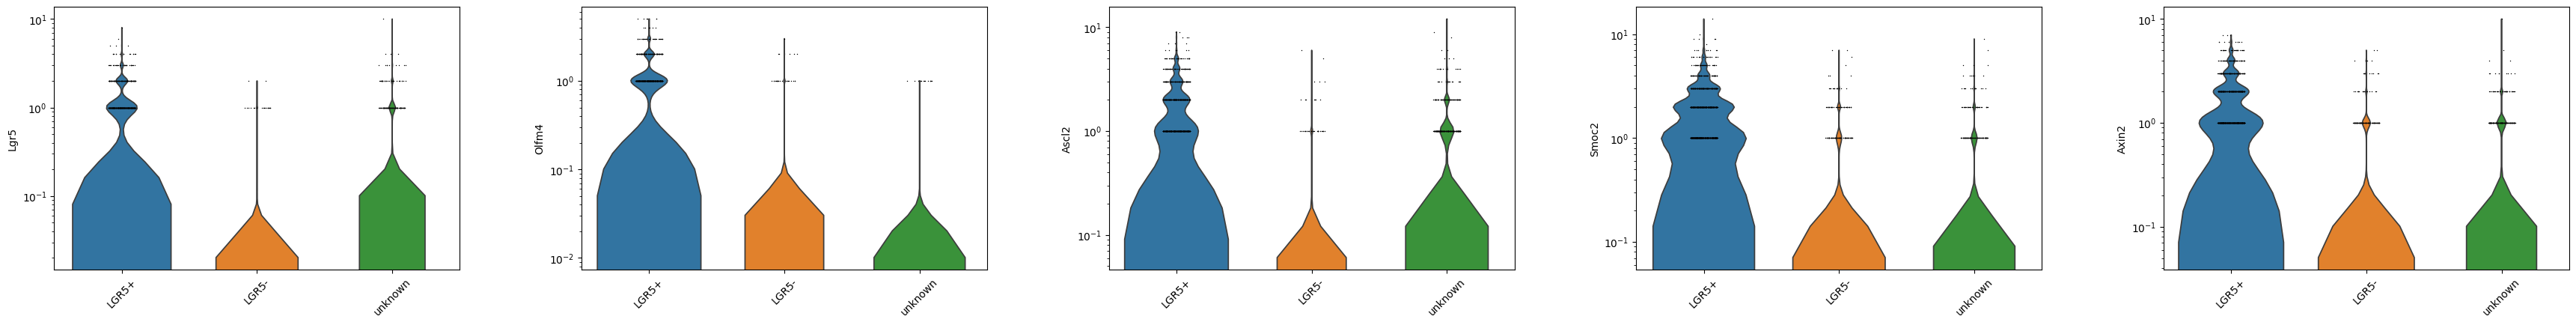

In [9]:
isc_markers = [g for g in ['Lgr5', 'Olfm4', 'Ascl2', 'Smoc2', 'Axin2'] if g in adata.var_names]
if isc_markers:
    sc.pl.violin(adata, isc_markers, groupby='lgr5_status', rotation=45, log=True)

### Record provenance and save

In [10]:
timestamp = datetime.now().strftime('%d%m%Y_%H%M%S')
adata.uns['GSE'] = 'GSE99457'
adata.uns['publication'] = 'Yan KS et al., Cell Stem Cell (2017) — Bmi1 vs Lgr5 ISC dynamics'
adata.uns['genome_reference'] = 'mm10 (per GEO upload, exact Ensembl/GENCODE version not declared)'
adata.uns['source_files'] = sorted(os.listdir(DATA_DIR))
adata.uns['processing_history'] = {
    timestamp: 'AnnData created from 10 GSE99457 10x mtx trios; concatenated outer-join; lgr5_status/lgr5_label_raw/condition/cell_type assigned per sample; QC metrics computed; no filtering applied. | note: GSM2644354_Prox1_2 is near-empty (~25 cells); flag for downstream QC drop.',
}

out_dir = 'data/LGR5_analysis'
os.makedirs(out_dir, exist_ok=True)
out_path = f'{out_dir}/gut_mm_GSE99457_AM_{timestamp}_raw.h5ad'
adata.write_h5ad(out_path)
print(out_path, adata.shape)

data/LGR5_analysis/gut_mm_GSE99457_AM_07052026_233711_raw.h5ad (5570, 27998)
